In [150]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pywaffle import Waffle
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from textwrap import wrap

con = sqlite3.connect('f1_data.db')
driver_colors = {
    # Red Bull Racing (dark blue)
    "Max Verstappen":      "#3671C6",
    "Sergio Perez":        "#134284",

    # Mercedes (teal/silver)
    "Lewis Hamilton":      "#27F4D2",
    "George Russell":      "#12B297",
    "Valtteri Bottas":     "#27F4D2",

    # Ferrari (red)
    "Charles Leclerc":     "#E8002D",
    "Carlos Sainz":        "#8C0721",
    "Oliver Bearman":      "#E8385B",

    # McLaren (papaya orange)
    "Lando Norris":        "#FF8000",
    "Oscar Piastri":       "#FF8000",
    "Daniel Ricciardo":    "#FF8000",

    # Alpine (blue/pink)
    "Fernando Alonso":     "#2293D1",
    "Esteban Ocon":        "#2293D1",
    "Pierre Gasly":        "#2293D1",

    # Aston Martin (green)
    "Lance Stroll":        "#229971",
    "Sebastian Vettel":    "#229971",
    "Nico Hulkenberg":     "#229971",

    # AlphaTauri / RB (navy/white)
    "Yuki Tsunoda":        "#6692FF",
    "Nyck De Vries":       "#6692FF",
    "Liam Lawson":         "#6692FF",

    # Alfa Romeo / Kick Sauber (maroon)
    "Guanyu Zhou":         "#C92D4B",
    "Antonio Giovinazzi":  "#C92D4B",
    "Kimi Räikkönen":      "#C92D4B",
    "Robert Kubica":       "#C92D4B",

    # Haas (white/red)
    "Kevin Magnussen":     "#B6BABD",
    "Mick Schumacher":     "#B6BABD",
    "Nikita Mazepin":      "#B6BABD",

    # Williams (blue)
    "Alexander Albon":     "#64C4FF",
    "Nicholas Latifi":     "#64C4FF",
    "Logan Sargeant":      "#64C4FF",
    "Franco Colapinto":    "#64C4FF",
}

constructor_colors = {
    "Red Bull Racing":  "#3671C6",
    "Mercedes":         "#27F4D2",
    "Ferrari":          "#E8002D",
    "McLaren":          "#FF8000",
    "Alpine":           "#2293D1",
    "Aston Martin":     "#229971",
    "AlphaTauri":       "#6692FF",
    "RB":               "#6692FF",  # AlphaTauri rebranded to RB in 2024
    "Alfa Romeo":       "#C92D4B",
    "Kick Sauber":      "#C92D4B",  # Alfa Romeo rebranded to Kick Sauber in 2024
    "Haas F1 Team":     "#B6BABD",
    "Williams":         "#64C4FF",
}


# F1 data analysis
### In this notebook it is going to be investigated some Formula 1 data from 2021 to 2024. Main idea is to see how does qualifying position depend on driver finish. Then, it is great to see who is making the biggest amount of successfull overtakes per race. Then, to research what was happening in the 2021, when Max and Lewis were both very close to the tittle, but only one got it. And to see, what happened after that year, and how tide was title race

# Reading info from database using SQL query

In [151]:
results = pd.read_sql_query("""
                            SELECT  r.race_Id, r.driver_id,d.full_name, c.name as constructor_name, r.grid_position, r.finish_position, r.points, q.q1,q.q2,q.q3, rc.race_name, rc.season
                            From race_results as r
                            inner join drivers as d on r.driver_id = d.driver_Id
                            inner join constructors as c on r.constructor_id = c.constructor_id
                            inner join qualifying_results as q on r.race_Id = q.race_Id and r.driver_id = q.driver_Id
                            inner join races as rc on r.race_id = rc.race_id
                            where rc.season < 2024 
                            """, con)

con.close()
results.head()


,race_id,driver_id,full_name,constructor_name,grid_position,finish_position,points,q1,q2,q3,race_name,season
0,202101,HAM,Lewis Hamilton,Mercedes,2.0,1.0,25.0,0 days 00:01:30.617000,0 days 00:01:30.085000,0 days 00:01:29.385000,Bahrain Grand Prix,2021
1,202101,VER,Max Verstappen,Red Bull Racing,1.0,2.0,18.0,0 days 00:01:30.499000,0 days 00:01:30.318000,0 days 00:01:28.997000,Bahrain Grand Prix,2021
2,202101,BOT,Valtteri Bottas,Mercedes,3.0,3.0,16.0,0 days 00:01:31.200000,0 days 00:01:30.186000,0 days 00:01:29.586000,Bahrain Grand Prix,2021
3,202101,NOR,Lando Norris,McLaren,7.0,4.0,12.0,0 days 00:01:30.902000,0 days 00:01:30.099000,0 days 00:01:29.974000,Bahrain Grand Prix,2021
4,202101,PER,Sergio Perez,Red Bull Racing,0.0,5.0,10.0,0 days 00:01:31.165000,0 days 00:01:30.659000,None,Bahrain Grand Prix,2021


# Handling missing data 

In [152]:
results.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1320 entries, 0 to 1319
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   race_id           1320 non-null   int64  
 1   driver_id         1320 non-null   object 
 2   full_name         1320 non-null   object 
 3   constructor_name  1320 non-null   object 
 4   grid_position     1257 non-null   float64
 5   finish_position   1257 non-null   float64
 6   points            1260 non-null   float64
 7   q1                1187 non-null   object 
 8   q2                888 non-null    object 
 9   q3                585 non-null    object 
 10  race_name         1320 non-null   object 
 11  season            1320 non-null   int64  
dtypes: float64(3), int64(2), object(7)
memory usage: 123.9+ KB


In [153]:
results.describe()

,race_id,grid_position,finish_position,points,season
count,1320.000000,1257.000000,1257.000000,1260.000000,1320.000000
mean,202211.500000,10.167064,10.477327,5.053571,2022.000000
std,81.926806,5.825277,5.756719,7.219421,0.816806
min,202101.000000,0.000000,1.000000,0.000000,2021.000000
25%,202117.000000,5.000000,5.000000,0.000000,2021.000000
50%,202211.500000,10.000000,10.000000,0.250000,2022.000000
75%,202306.000000,15.000000,15.000000,9.000000,2023.000000
max,202322.000000,20.000000,20.000000,26.000000,2023.000000


In [154]:
print(results["finish_position"].isna().sum())

63


In [155]:
print(results["grid_position"].isna().sum())

63


I found **262** null valueі in "finish_position" and in "grid_position" column. I didn't find any information about those races, there are some results in the Internet, but no info in API, I think it is relevant to drop those values, because they will not affect by any way on the future analysis 

In [156]:
results = results.dropna(subset=["finish_position"])

In [157]:
results.isna().sum()

race_id               0
driver_id             0
full_name             0
constructor_name      0
grid_position         0
finish_position       0
points                0
q1                   72
q2                  369
q3                  672
race_name             0
season                0
dtype: int64

Now, we are sure that there are no null value in positions, and points, then we have to handle q1,q2,q3 null values. We will replace null to 0, because null means that drivers didn't get to q2  or q3. Or they didn't start the sessions, and the started from the back.

In [158]:
results["q1"].replace({np.nan: 0}, inplace=True)
results["q2"].replace({np.nan: 0}, inplace=True)
results["q3"].replace({np.nan: 0}, inplace=True)

In [159]:
results.isna().sum()

race_id             0
driver_id           0
full_name           0
constructor_name    0
grid_position       0
finish_position     0
points              0
q1                  0
q2                  0
q3                  0
race_name           0
season              0
dtype: int64

We handled missing data, we can move on to EDA

# EDA

First important thing I wanted to see is correlation between quali results and race results

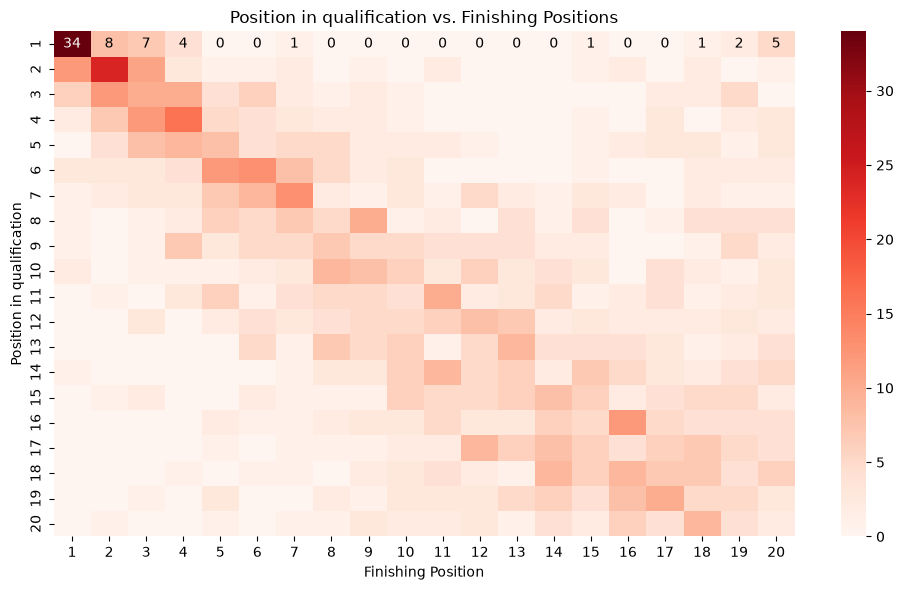

In [160]:
plot_data = results[["grid_position", "finish_position"]].copy()
plot_data["grid_position"] = plot_data["grid_position"].astype(int)
plot_data["finish_position"] = plot_data["finish_position"].astype(int)

heatmap_data = pd.crosstab(
    plot_data["grid_position"],
    plot_data["finish_position"]
).reindex(index=range(1, 21), columns=range(1, 21), fill_value=0)

plt.figure(figsize=(10, 6))
ax =sns.heatmap(
    heatmap_data,
    cmap="Reds",
    annot=False,
    fmt="d",
    cbar=True,
    linewidths= 0
)

for col, value in enumerate(heatmap_data.iloc[0]):
    ax.text(
        col + 0.5,
        0.5,
        int(value),
        ha="center",
        va="center",
        color="white" if value > heatmap_data.values.max() / 2 else "black"
    )

plt.title("Position in qualification vs. Finishing Positions")
plt.xlabel("Finishing Position")
plt.ylabel("Position in qualification") 
plt.tight_layout()
plt.show()


It is can be seen that position in qualification very often determines your finishing position. Sometimes it is as important as the race

*The next very interesting point to look at is which of the drivers has the highest realisation of its grid position* 

In [161]:
results_analysis = results.copy()
results_analysis["avg_gained_positions"] =results_analysis.groupby("driver_id")["grid_position"].transform(lambda x: (x - results_analysis["finish_position"]).mean())

avg_gained_postions_rank = results_analysis[["full_name", "avg_gained_positions"]].drop_duplicates().sort_values(by="avg_gained_positions", ascending=False).head(10)
avg_gained_postions_rank

,full_name,avg_gained_positions
254,Robert Kubica,2.000000
1132,Liam Lawson,1.600000
891,Logan Sargeant,1.450000
9,Lance Stroll,1.370968
473,Alexander Albon,0.675000
19,Nikita Mazepin,0.666667
748,Nyck De Vries,0.545455
1,Max Verstappen,0.412698
17,Nicholas Latifi,0.395349
470,Guanyu Zhou,0.268293


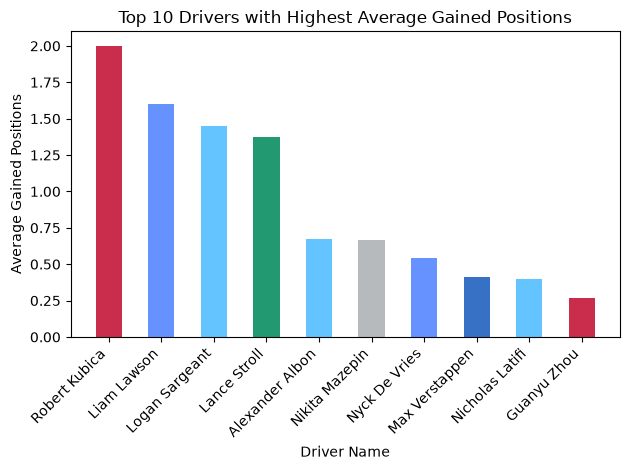

In [162]:
plt.bar(avg_gained_postions_rank["full_name"], avg_gained_postions_rank["avg_gained_positions"], width=0.5, color = [driver_colors.get(name, "#333333") for name in avg_gained_postions_rank["full_name"]])
plt.title("Top 10 Drivers with Highest Average Gained Positions")
plt.xlabel("Driver Name")
plt.ylabel("Average Gained Positions")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Next we will look at the number of gained points by drivers and then the teams

In [163]:
results_analysis["sum_of_points"] = results_analysis.groupby("driver_id")["points"].transform("sum")
top_gained_points = results_analysis[["full_name","sum_of_points"]].drop_duplicates().sort_values(by="sum_of_points", ascending=False).head(10)
top_gained_points

,full_name,sum_of_points
1,Max Verstappen,1301.5
0,Lewis Hamilton,795.5
4,Sergio Perez,726.0
5,Charles Leclerc,576.0
7,Carlos Sainz,531.5
3,Lando Norris,450.0
13,George Russell,411.0
18,Fernando Alonso,356.0
2,Valtteri Bottas,268.0
12,Esteban Ocon,200.0


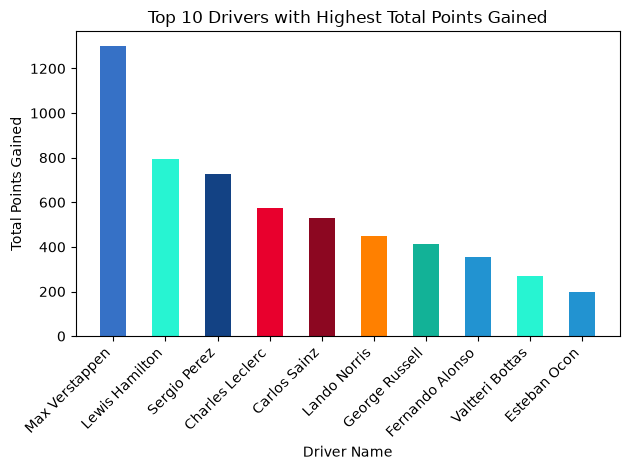

In [164]:
plt.bar(top_gained_points["full_name"], top_gained_points["sum_of_points"], width=0.5,color = [driver_colors.get(name, "#333333") for name in top_gained_points["full_name"]])
plt.title("Top 10 Drivers with Highest Total Points Gained")
plt.xlabel("Driver Name")
plt.ylabel("Total Points Gained")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Let's see how much points did Max Verstappen take from all of the points for these years

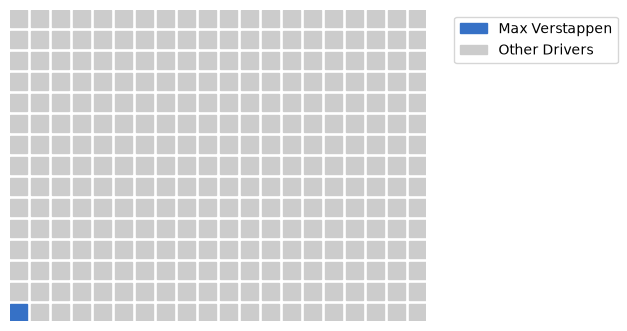

In [165]:
max_points = results_analysis["sum_of_points"].where(results_analysis["full_name"]=="Max Verstappen").dropna().values[0]
data={
    "Max Verstappen": max_points,
    "Other Drivers": results_analysis["sum_of_points"].sum() - max_points
}
plt.figure(
    FigureClass=Waffle,
    rows=15,
    columns=20,
    values=data,
    legend={'loc': 'upper left', 'bbox_to_anchor': (1.05, 1)},
    colors=[driver_colors.get("Max Verstappen", "#333333"), "#CCCCCC"],
)
plt.show()

In [166]:
percentage_max = (max_points / results_analysis["sum_of_points"].sum()) * 100
print(percentage_max)

0.33269129749606025


Although, Max has the highest number of points, it is still 0.3% of all points gained from 2021 to 2024

In [167]:
results_analysis["sum_of_points_constructor"] = results_analysis.groupby("constructor_name")["points"].transform("sum")
top_gained_points_by_constructor = results_analysis[["constructor_name","sum_of_points_constructor"]].drop_duplicates().sort_values(by="sum_of_points_constructor", ascending=False).head(10)
top_gained_points_by_constructor

,constructor_name,sum_of_points_constructor
1,Red Bull Racing,2027.5
0,Mercedes,1409.5
5,Ferrari,1107.5
3,McLaren,674.0
12,Alpine,414.0
9,Aston Martin,386.0
8,AlphaTauri,189.0
10,Alfa Romeo,73.0
13,Williams,55.0
15,Haas F1 Team,32.0


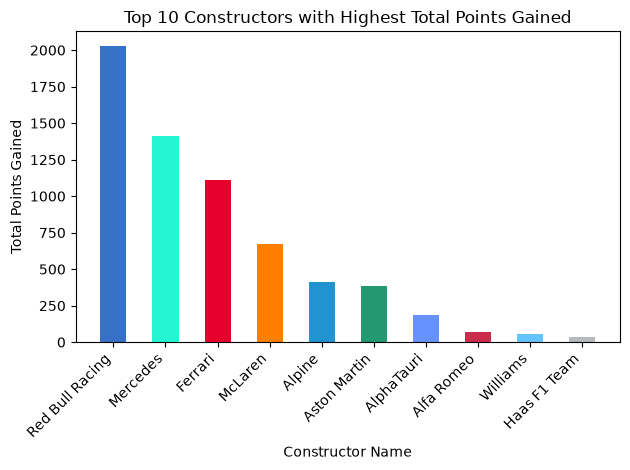

In [168]:
plt.bar(top_gained_points_by_constructor["constructor_name"], top_gained_points_by_constructor["sum_of_points_constructor"],width=0.5,color = [constructor_colors.get(name, "#333333") for name in top_gained_points_by_constructor["constructor_name"]])
plt.title("Top 10 Constructors with Highest Total Points Gained")
plt.xlabel("Constructor Name")
plt.ylabel("Total Points Gained")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

We can see that if we would compare Max Verstappen to the whole teams(excluding his team Red Bull Racing), Max would be on the second place with 99 points difference with Mercedes team. 

Lets visualize it

In [169]:
results_analysis_1 = results_analysis.copy()
max_points_df = pd.DataFrame({"constructor_name": ["Max Verstappen"], "sum_of_points_constructor": max_points})
results_analysis_1 = pd.concat([results_analysis_1,max_points_df], ignore_index=True)
results_analysis_1 = results_analysis_1.sort_values(by="sum_of_points_constructor", ascending=False).drop_duplicates(subset=["constructor_name"], keep="first")
results_analysis_1 = results_analysis_1[["constructor_name","sum_of_points_constructor"]].head(10)
results_analysis_1

,constructor_name,sum_of_points_constructor
759,Red Bull Racing,2027.5
21,Mercedes,1409.5
1257,Max Verstappen,1301.5
477,Ferrari,1107.5
592,McLaren,674.0
612,Alpine,414.0
795,Aston Martin,386.0
466,AlphaTauri,189.0
1209,Alfa Romeo,73.0
1105,Williams,55.0


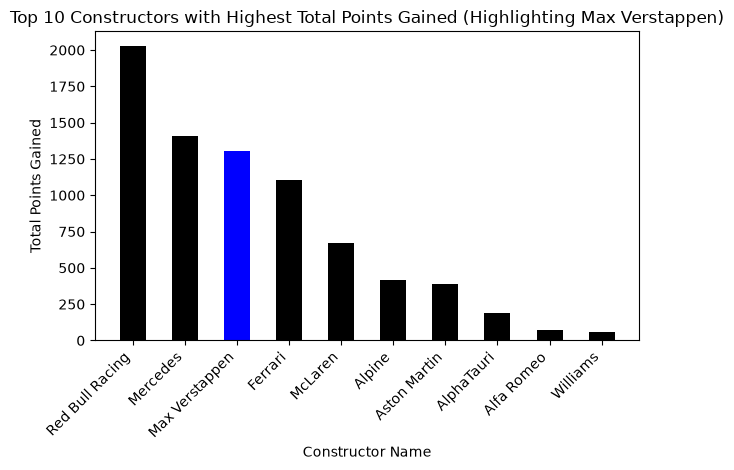

In [170]:
plt.bar(results_analysis_1["constructor_name"], results_analysis_1["sum_of_points_constructor"], width=0.5, color=['blue' if name == "Max Verstappen" else "#000000" for name in results_analysis_1["constructor_name"]] )
plt.title("Top 10 Constructors with Highest Total Points Gained (Highlighting Max Verstappen)")
plt.xlabel("Constructor Name")
plt.ylabel("Total Points Gained")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Now, we will see what the difference is from 2022-2024, because 2021 was a year where the Max's domination has not started yet.

In [171]:
results_analysis["sum_of_points_after_2021"] = results_analysis.where(lambda x: results_analysis["season"] > 2021).groupby("driver_id")["points"].transform("sum")
results_analysis_after_2021 = results_analysis[["full_name","sum_of_points_after_2021"]].drop_duplicates().sort_values(by="sum_of_points_after_2021", ascending=False).head(10)
results_analysis_after_2021

,full_name,sum_of_points_after_2021
460,Max Verstappen,913.0
463,Sergio Perez,536.0
461,Charles Leclerc,417.0
469,Lewis Hamilton,410.0
464,George Russell,395.0
462,Carlos Sainz,368.0
466,Lando Norris,290.0
475,Fernando Alonso,275.0
465,Esteban Ocon,126.0
467,Pierre Gasly,77.0


We can see that point difference is huge

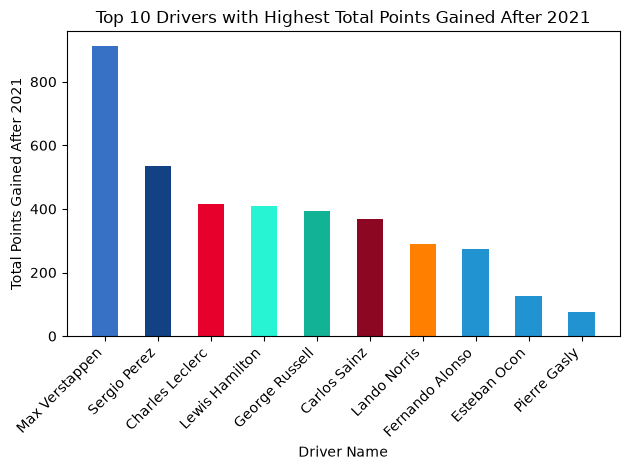

In [172]:
plt.bar(results_analysis_after_2021["full_name"], results_analysis_after_2021["sum_of_points_after_2021"], width=0.5, color = [driver_colors.get(name, "#333333") for name in results_analysis_after_2021["full_name"]])
plt.title("Top 10 Drivers with Highest Total Points Gained After 2021")
plt.xlabel("Driver Name")
plt.ylabel("Total Points Gained After 2021")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Now, lets see the same graph of waffle

Out of all gained points Max took: 23.98213816653533%


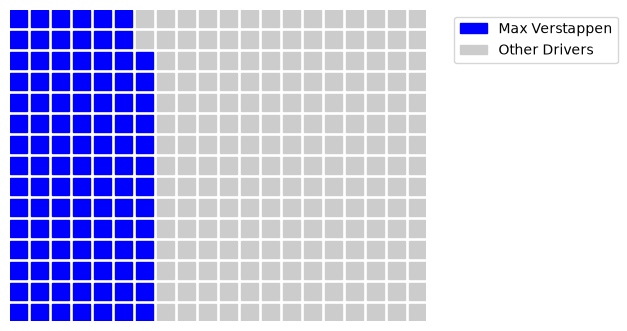

In [173]:
max_points_after_2021 = results_analysis_after_2021["sum_of_points_after_2021"].where(results_analysis_after_2021["full_name"]=="Max Verstappen").dropna().values[0]
data={
    "Max Verstappen": max_points,
    "Other Drivers": results_analysis_after_2021["sum_of_points_after_2021"].sum() - max_points
}
plt.figure(
    FigureClass=Waffle,
    rows=15,
    columns=20,
    values=data,
    legend={'loc': 'upper left', 'bbox_to_anchor': (1.05, 1)},
    colors=["blue","#CCCCCC"]
)
percentage_max = (max_points_after_2021 / results_analysis_after_2021["sum_of_points_after_2021"].sum()) * 100
print(f"Out of all gained points Max took: {percentage_max}%")
plt.show()

Now, we can see how the domination changed everything. Lets compare to the constructors again

In [174]:
results_analysis["sum_of_points_constructors_after_2021"] = results_analysis.where(lambda x: results_analysis["season"] > 2021).groupby("constructor_name")["points"].transform("sum")
top_gained_points_by_constructor_after_2021 = results_analysis[["constructor_name","sum_of_points_constructors_after_2021"]].drop_duplicates().sort_values(by="sum_of_points_constructors_after_2021", ascending=False).head(10)
top_gained_points_by_constructor_after_2021

,constructor_name,sum_of_points_constructors_after_2021
460,Red Bull Racing,1449.0
464,Mercedes,805.0
461,Ferrari,785.0
466,McLaren,400.0
471,Aston Martin,309.0
465,Alpine,259.0
470,Alfa Romeo,60.0
467,AlphaTauri,47.0
468,Haas F1 Team,32.0
473,Williams,32.0


After 2021 Max Verstappen gained more points than all teams(excluding his team), he can be compared only with the teams.

In [175]:
max_points_after_2021_df = pd.DataFrame({"constructor_name": ["Max Verstappen"], "sum_of_points_constructors_after_2021": max_points_after_2021})
top_gained_points_by_constructor_after_2021 = pd.concat([top_gained_points_by_constructor_after_2021, max_points_after_2021_df])
top_gained_points_by_constructor_after_2021 = top_gained_points_by_constructor_after_2021.sort_values(by="sum_of_points_constructors_after_2021",ascending=False)
top_gained_points_by_constructor_after_2021 = top_gained_points_by_constructor_after_2021.drop(top_gained_points_by_constructor_after_2021[top_gained_points_by_constructor_after_2021['constructor_name'] == "Red Bull Racing"].index)
top_gained_points_by_constructor_after_2021.head(10)

,constructor_name,sum_of_points_constructors_after_2021
0,Max Verstappen,913.0
464,Mercedes,805.0
461,Ferrari,785.0
466,McLaren,400.0
471,Aston Martin,309.0
465,Alpine,259.0
470,Alfa Romeo,60.0
467,AlphaTauri,47.0
468,Haas F1 Team,32.0
473,Williams,32.0


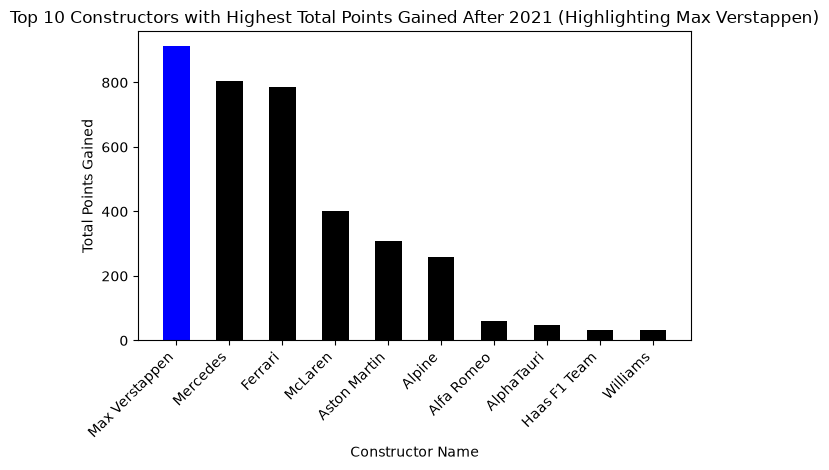

In [176]:
plt.bar(top_gained_points_by_constructor_after_2021["constructor_name"], top_gained_points_by_constructor_after_2021["sum_of_points_constructors_after_2021"], width=0.5, color=['blue' if name == "Max Verstappen" else '#000000' for name in top_gained_points_by_constructor_after_2021["constructor_name"]])
plt.title("Top 10 Constructors with Highest Total Points Gained After 2021 (Highlighting Max Verstappen)")
plt.xlabel("Constructor Name")
plt.ylabel("Total Points Gained")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Let's Investigate how the situation in the driver standings looked in the most competing year - 2021

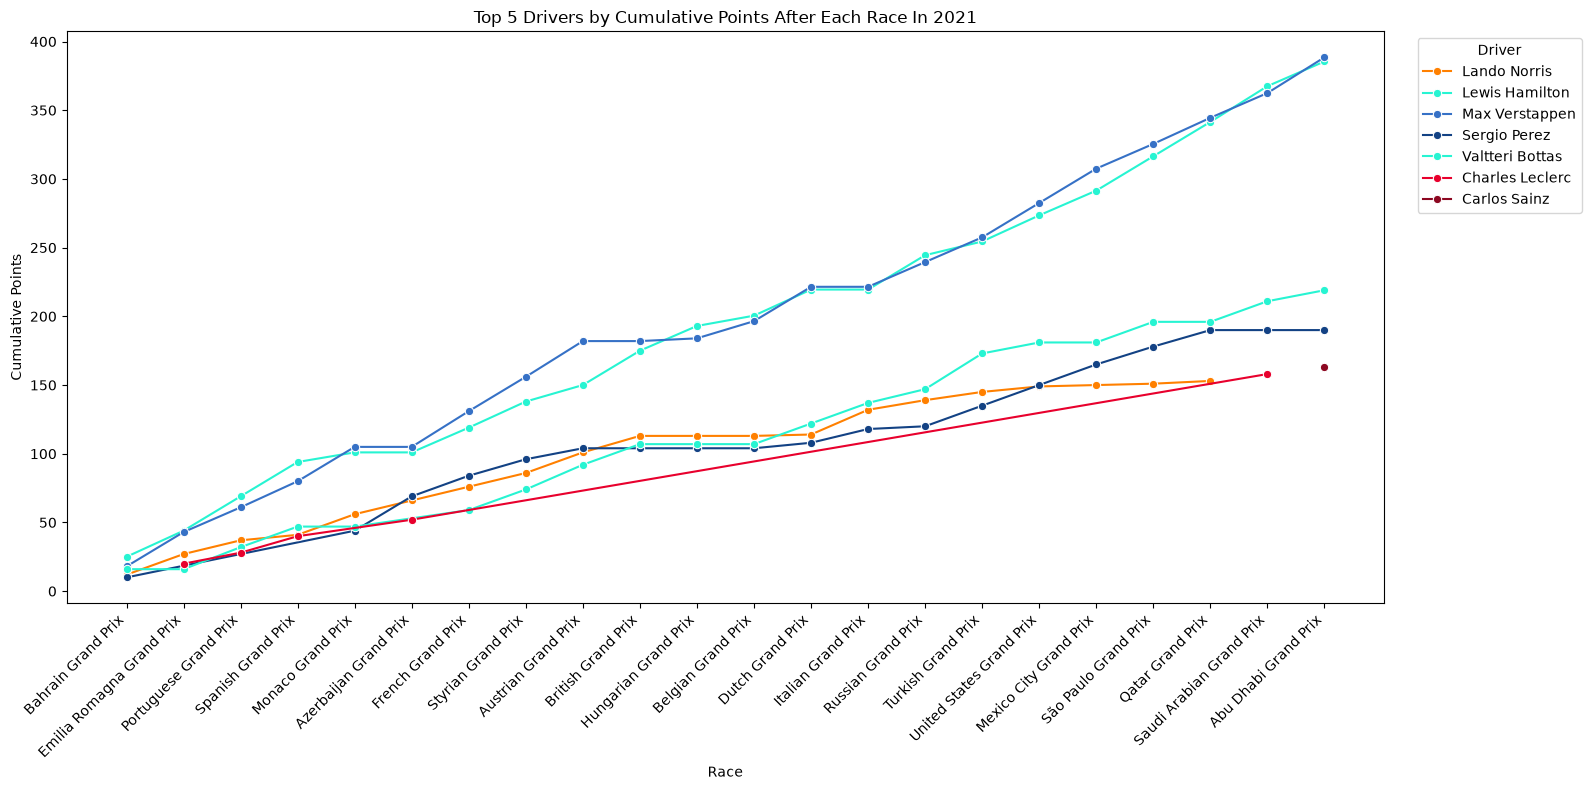

In [177]:
# Build cumulative points by race
# used copilot for this section



standings = results_analysis[results_analysis["season"] == 2021].copy()

# Some race_result tables may contain multiple rows per driver/race in edge cases,
# so aggregate safely to one row per driver per race
standings = (
    standings
    .groupby(["race_id", "season", "race_name", "full_name"], as_index=False)["points"]
    .sum()
)

# Ensure races are in chronological order
race_order = (
    standings[["race_id", "season", "race_name"]]
    .drop_duplicates()
    .sort_values(["season", "race_id"])
)
race_order["race_round"] = np.arange(1, len(race_order) + 1)

standings = standings.merge(race_order, on=["race_id", "season", "race_name"], how="left")
standings = standings.sort_values(["race_round", "full_name"])

# Cumulative points per driver after each race
standings["cumulative_points"] = standings.groupby("full_name")["points"].cumsum()

# Driver rank after each race
standings["rank_after_race"] = (
    standings.groupby("race_round")["cumulative_points"]
    .rank(method="dense", ascending=False)
)

top5_each_race = standings[standings["rank_after_race"] <= 5].copy()

# Keep x-axis readable
top5_each_race["race_label"] = (
    top5_each_race["season"].astype(str) + " - " + top5_each_race["race_name"]
)

plt.figure(figsize=(16, 8))
sns.lineplot(
    data=top5_each_race,
    x="race_round",
    y="cumulative_points",
    hue="full_name",
    marker="o",
    palette= driver_colors
)

# Show fewer x ticks for readability
tick_step = max(1, len(race_order) // 12)
tick_positions = race_order["race_round"].iloc[::tick_step]
tick_labels = (
    race_order["race_name"]
).iloc[::tick_step]

plt.xticks(tick_positions, tick_labels, rotation=45, ha="right")
plt.title("Top 5 Drivers by Cumulative Points After Each Race In 2021")
plt.xlabel("Race")
plt.ylabel("Cumulative Points")
plt.legend(title="Driver", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

**Let's compare drivers with the violin plot of gained position.**

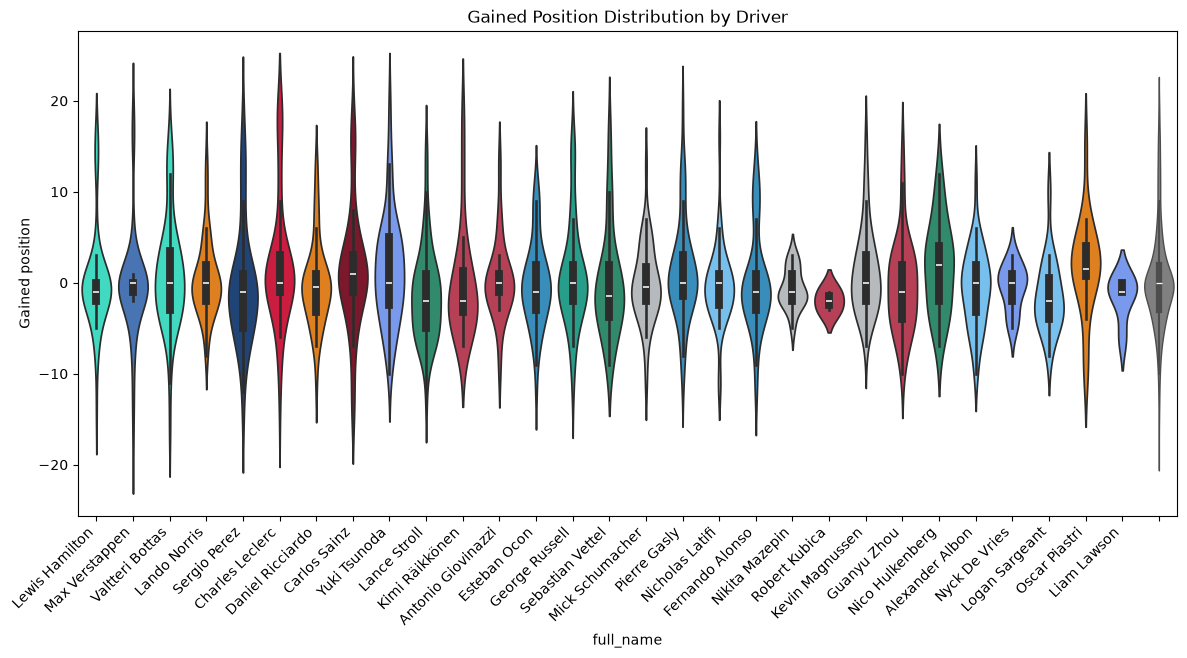

In [190]:
results_analysis["gained_position"] = results_analysis["finish_position"] - results_analysis["grid_position"]


plt.figure(figsize=(12, 18))

plt.subplot(3, 1, 1)
sns.violinplot(x=results_analysis['full_name'], y=results_analysis['gained_position'], palette=driver_colors, hue=results_analysis["full_name"])
sns.violinplot(y=results_analysis['gained_position'], color='gray', linewidth=1.0)
plt.title('Gained Position Distribution by Driver')
plt.ylabel('Gained position')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()


**Lets see the violin plot of finishing and qulifying**

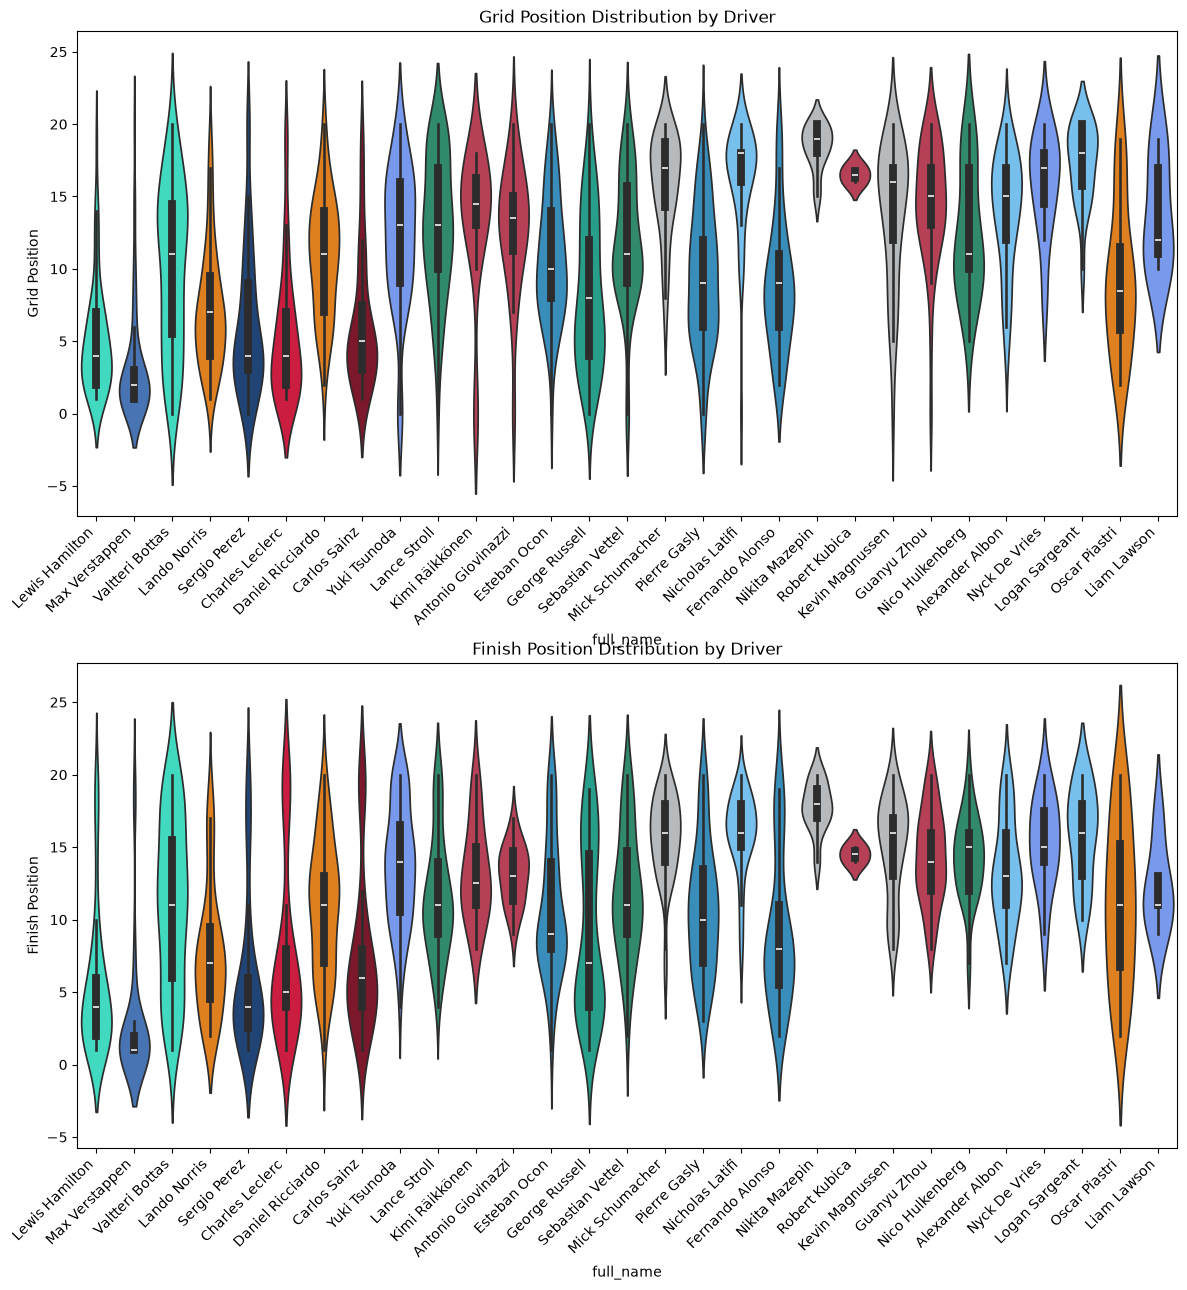

In [194]:
plt.figure(figsize=(12, 18))
plt.subplot(3, 1, 1)
sns.violinplot(x=results_analysis["full_name"], y=results_analysis["grid_position"], palette=driver_colors, hue=results_analysis["full_name"])
plt.title("Grid Position Distribution by Driver")
plt.ylabel("Grid Position")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.subplot(3, 1, 2)
sns.violinplot(x=results_analysis["full_name"], y=results_analysis["finish_position"], palette=driver_colors, hue=results_analysis["full_name"])
plt.title("Finish Position Distribution by Driver")
plt.ylabel("Finish Position")
plt.xticks(rotation=45, ha='right')


plt.show()

# Key Insights from the analysis
- Position in qualifying almost everytime determines the winner. In 55 times out of 70 qulifying winner took podium
- *Robert Kubica* is the driver who does the biggest amount of successful overtakes
-  **Max Verstappen** as the champion was flawless during these years, his success could be compared with whole constructors. After becoming a champion he gained almost 1/4 of all points.
- Red Bull Racing was the most successfull team throught all the researched time.